In [91]:
import os
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import rasterio
from pyproj import Transformer
import random

In [92]:
files_dir  = "./data_clip_exolabs"

#get all files in dir 
files = os.listdir(files_dir)
print(files)

#load tif 


tif_files = [] #LOAD all .tif 
for file in files:
    src = rasterio.open(os.path.join(files_dir, file))
    tif_files.append(src.read(1))


['2023-04-27+000_alps_HS_product.tif', '2023-04-19+000_alps_HS_product.tif', '2023-06-25+000_alps_HS_product.tif', '2023-05-06+000_alps_HS_product.tif', '2023-05-09+000_alps_HS_product.tif', '2023-06-14+000_alps_HS_product.tif', '2023-04-16+000_alps_HS_product.tif', '2023-04-28+000_alps_HS_product.tif', '2023-04-05+000_alps_HS_product.tif', '2023-06-07+000_alps_HS_product.tif', '2023-05-24+000_alps_HS_product.tif', '2023-05-15+000_alps_HS_product.tif', '2023-06-08+000_alps_HS_product.tif', '2023-06-10+000_alps_HS_product.tif', '2023-04-12+000_alps_HS_product.tif', '2023-04-23+000_alps_HS_product.tif', '2023-05-02+000_alps_HS_product.tif', '2023-06-21+000_alps_HS_product.tif', '2023-05-11+000_alps_HS_product.tif', '2023-04-30+000_alps_HS_product.tif', '2023-04-01+000_alps_HS_product.tif', '2023-05-20+000_alps_HS_product.tif', '2023-06-03+000_alps_HS_product.tif', '2023-05-12+000_alps_HS_product.tif', '2023-04-02+000_alps_HS_product.tif', '2023-05-23+000_alps_HS_product.tif', '2023-06-13

In [93]:
###EXPLORING THE FORMAT OF COORDINATE SYSTEM
with rasterio.open('./data_clip_exolabs/2023-04-01+000_alps_HS_product.tif') as src:
    # Check metadata
    print(src.crs)  # Coordinate Reference System (CRS)
    print(src.bounds)  # Bounding box (min, max) coordinates
    print(src.transform)

EPSG:3857
BoundingBox(left=829059.4892686082, bottom=5860743.433705239, right=938039.4892686082, top=5927163.433705239)
| 20.00, 0.00, 829059.49|
| 0.00,-20.00, 5927163.43|
| 0.00, 0.00, 1.00|


In [94]:
###EXPLORE AVALANCHE DATA FROM SLF

avalanche_data = pd.read_csv('./data_SLF_avalanche.csv')
print(avalanche_data.head())
print(avalanche_data.columns)

                           avalanche_id                   location  \
0  f9d63b0f-4a9d-443d-9df5-30e8ba818ef2   POINT(9.80967 46.832453)   
1  216c2530-d139-11ed-80fa-f54d650c1715   POINT(7.74259 46.055277)   
2  d58cf800-d139-11ed-af01-234d49385de9  POINT(7.737122 46.047328)   
3  36855710-d13a-11ed-af01-234d49385de9  POINT(7.736374 46.053393)   
4  6ab88170-d157-11ed-991a-6bfa9504affb  POINT(8.936376 46.932609)   

               trigger_date_time  trigger_date_time_accuracy_code  \
0  2023-04-01 10:44:00.000 +0200                                1   
1  2023-04-02 10:05:00.000 +0200                                0   
2  2023-04-02 09:55:00.000 +0200                                0   
3  2023-04-02 09:54:00.000 +0200                                0   
4  2023-04-02 14:20:00.000 +0200                                0   

  trigger_type avalanche_type  avalanche_size avalanche_moisture  \
0       PERSON           SLAB               2                DRY   
1    EXPLOSIVE           SLA

In [95]:
avalanche_data['location']
#string POINT(9.80967 46.832453)  
#remove POINT( and )
avalanche_data['location'] = avalanche_data['location'].str.replace('POINT(', '').str.replace(')', '')
avalanche_data['lat'] = avalanche_data['location'].apply(lambda x: float(x.split(' ')[1]))
avalanche_data['lon'] = avalanche_data['location'].apply(lambda x: float(x.split(' ')[0]))
print(avalanche_data['lon'])

0       9.809670
1       7.742590
2       7.737122
3       7.736374
4       8.936376
          ...   
1691    8.971368
1692    7.045566
1693    7.797743
1694    7.747613
1695    7.745373
Name: lon, Length: 1696, dtype: float64


In [96]:
date = avalanche_data['trigger_date_time'][0].split(' ')[0]
date 
def tif_path_from_date(date):
    return f"./data_clip_exolabs/{date}+000_alps_HS_product.tif"

new_df = pd.DataFrame(columns=['avalanche_id', 'location', 'trigger_date_time',
       'trigger_date_time_accuracy_code', 'trigger_type', 'avalanche_type',
       'avalanche_size', 'avalanche_moisture', 'start_zone_aspect', 'snow_depth_sat'])

In [97]:
new_df.head()


,avalanche_id,location,trigger_date_time,trigger_date_time_accuracy_code,trigger_type,avalanche_type,avalanche_size,avalanche_moisture,start_zone_aspect,snow_depth_sat


In [98]:
###FILTER ONLY POINT IN BOUNDS OF SAT DATA -> EXPORT SNOW DEPTH FROM SATELITE




transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)


for _, row in avalanche_data.iterrows():
    date = row['trigger_date_time'].split(' ')[0]
    tif_path = tif_path_from_date(date)

    with rasterio.open(tif_path) as tif_map:
        bounds = tif_map.bounds
        lon = row['lon']
        lat = row['lat']
        x_3857, y_3857 = transformer.transform(lon, lat)

        if bounds.left <= x_3857 <= bounds.right and bounds.bottom <= y_3857 <= bounds.top:
                row_px, col_px = tif_map.index(x_3857, y_3857)
                snow_depth_sat = tif_map.read(1)[row_px, col_px]

                new_df = pd.concat([new_df, pd.DataFrame([row])], ignore_index=True)
                new_df.at[new_df.index[-1], 'snow_depth_sat'] = snow_depth_sat



In [99]:
#IMPUTE RANDOM POINTS 
#idea : for each point where there's avalanche , we take 10 random points within 1-5km spacial radius and 0-3 timestep and add them to the dataset
new_df["Avalanche Event"] = 1

# Create a new DataFrame to store the random points
random_points_df = pd.DataFrame(columns=new_df.columns)

for index, row in new_df.iterrows():
    # Generate 10 random points within a radius of 1-5km
    for _ in range(9):
       
        lat_offset = random.uniform(-0.045, 0.045)  # Approx. 5 km in degrees
        lon_offset = random.uniform(-0.045, 0.045)  # Approx. 5 km in degrees

        days_offset = random.randint(0, 3)

        # Create a new row with the random point
        random_row = row.copy()
        random_row['lat'] += lat_offset
        random_row['lon'] += lon_offset
        random_row['trigger_date_time'] = pd.to_datetime(row['trigger_date_time']) + pd.Timedelta(days=days_offset)
        random_row['Avalanche Event'] = 0

        # Append the random point to the new DataFrame
        random_points_df = pd.concat([random_points_df, pd.DataFrame([random_row])], ignore_index=True)

new_df = pd.concat([new_df, random_points_df], ignore_index=True)
# Shuffle the DataFrame
new_df = new_df.sample(frac=1).reset_index(drop=True)



/var/folders/lj/yyssz_p12f50nl5zkgxpqy5h0000gn/T/ipykernel_38872/3917566034.py:25: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  random_points_df = pd.concat([random_points_df, pd.DataFrame([random_row])], ignore_index=True)


In [101]:
new_df.head()

,avalanche_id,location,trigger_date_time,trigger_date_time_accuracy_code,trigger_type,avalanche_type,avalanche_size,avalanche_moisture,start_zone_aspect,snow_depth_sat,lat,lon,Avalanche Event
0,0d6a183c-f453-4a31-98c7-90213921e278,8.417328 46.785788,2023-04-01 06:30:00.000 +0200,2,EXPLOSIVE,SLAB,1,DRY,NW,79,46.785788,8.417328,1
1,a7ed94b7-52d1-4b17-9928-83b4745ca8bf,8.307745 46.608205,2023-05-04 12:00:00+02:00,7,NATURAL,UNKNOWN,3,WET,NaN,35,46.584697,8.297091,0
2,673e5d3c-9736-4824-ac24-c511ffd507c4,8.418437 46.784875,2023-04-18 08:00:00+02:00,4,EXPLOSIVE,SLAB,1,DRY,NW,169,46.810638,8.431794,0
3,74720590-2505-48bc-ad7b-327442e7d8ae,8.216759 46.608474,2023-04-22 12:00:00+02:00,7,PERSON,SLAB,1,DRY,N,130,46.617306,8.227025,0
4,a4ad0c82-16f6-4de1-af92-ac146cabf042,8.423474 46.779387,2023-05-02 07:30:00+02:00,4,EXPLOSIVE,SLAB,2,DRY,N,131,46.813750,8.419820,0


In [105]:
###UPDATE SNOW DEPTH ESTIMATION FROM .TIF

transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
point_out_of_bounds = 0

for _, row in new_df.iterrows():
    trigger_dt = pd.to_datetime(row['trigger_date_time'], utc=True)
    date_str = trigger_dt.strftime('%Y-%m-%d')
    tif_path = tif_path_from_date(date_str)

    with rasterio.open(tif_path) as tif_map:
        bounds = tif_map.bounds
        lon = row['lon']
        lat = row['lat']
        x_3857, y_3857 = transformer.transform(lon, lat)

        if bounds.left <= x_3857 <= bounds.right and bounds.bottom <= y_3857 <= bounds.top:
                row_px, col_px = tif_map.index(x_3857, y_3857)
                snow_depth_sat = tif_map.read(1)[row_px, col_px]

                new_df.at[_, 'snow_depth_sat'] = snow_depth_sat
        else :
            point_out_of_bounds+= 1 
            #delete row
            new_df = new_df.drop(index=_)

print(f"Number of points out of bounds: {point_out_of_bounds}")

Number of points out of bounds: 10


In [119]:
#INCLUDE ELEVATION DATA 



import requests
import rasterio
import numpy as np
from rasterio.io import MemoryFile


# Approximate conversion: 0.0025 degrees ~ 277 meters (depends on latitude)
buffer_deg = 0.0025  # roughly 250m buffer

lon, lat = 8.3, 46.8

min_lon = lon - buffer_deg
max_lon = lon + buffer_deg
min_lat = lat - buffer_deg
max_lat = lat + buffer_deg

bbox = (min_lon, min_lat, max_lon, max_lat)
print(f"Bounding box: {bbox}")


# Replace with your OpenTopography API key
api_key = 'd72fa5d73ec0817116fc75e39d9a6e8a'

# Choose a DEM dataset, e.g., 'SRTMGL1' for 30m resolution
dem_type = 'SRTMGL1'

# Construct the API URL
url = (
    f'https://portal.opentopography.org/API/globaldem?demtype={dem_type}'
    f'&south={min_lat}&north={max_lat}&west={min_lon}&east={max_lon}'
    f'&outputFormat=GTiff&API_Key={api_key}'
)
print(url)

response = requests.get(url)
if response.status_code == 200:
    with MemoryFile(response.content) as memfile:
        with memfile.open() as dataset:
            elevation_data = dataset.read(1)
            transform = dataset.transform
else:
    raise Exception(f"Error fetching data: {response.status_code}")


# Calculate gradients
x, y = np.gradient(elevation_data, dataset.res[0], dataset.res[1])

# Calculate slope in degrees
slope = np.degrees(np.arctan(np.sqrt(x**2 + y**2)))

# Calculate aspect in degrees
aspect = np.degrees(np.arctan2(-x, y))
aspect = np.where(aspect < 0, 360 + aspect, aspect)

from rasterio.transform import rowcol

row, col = rowcol(transform, longitude, latitude)

# Ensure the indices are within the array bounds
if (0 <= row < elevation_data.shape[0]) and (0 <= col < elevation_data.shape[1]):
    elevation = elevation_data[row, col]
    slope_value = slope[row, col]
    aspect_value = aspect[row, col]

    print(f"Elevation: {elevation} meters")
    print(f"Slope: {slope_value} degrees")
    print(f"Aspect: {aspect_value} degrees")
else:
    print("Point is outside the bounds of the retrieved data.")



Bounding box: (8.297500000000001, 46.7975, 8.3025, 46.802499999999995)
https://portal.opentopography.org/API/globaldem?demtype=SRTMGL1&south=46.7975&north=46.802499999999995&west=8.297500000000001&east=8.3025&outputFormat=GTiff&API_Key=d72fa5d73ec0817116fc75e39d9a6e8a
Elevation: 1561 meters
Slope: 89.99796222976693 degrees
Aspect: 320.1944289077348 degrees


In [120]:
import requests
import numpy as np
import pandas as pd
import rasterio
from rasterio.io import MemoryFile
from rasterio.transform import rowcol

# Your OpenTopography API key
api_key = 'd72fa5d73ec0817116fc75e39d9a6e8a'
dem_type = 'SRTMGL1'  # 30m resolution DEM

new_df["elevation"] = np.nan
new_df["slope"] = np.nan
new_df["aspect"] = np.nan

buffer_deg = 0.0025  # ~250m buffer around each point

def get_topo_data(lon, lat, buffer=buffer_deg):
    min_lon = lon - buffer
    max_lon = lon + buffer
    min_lat = lat - buffer
    max_lat = lat + buffer

    url = (
        f'https://portal.opentopography.org/API/globaldem?demtype={dem_type}'
        f'&south={min_lat}&north={max_lat}&west={min_lon}&east={max_lon}'
        f'&outputFormat=GTiff&API_Key={api_key}'
    )
    response = requests.get(url)
    if response.status_code != 200:
        raise Exception(f"Error fetching DEM data: {response.status_code}")
        
    
    with MemoryFile(response.content) as memfile:
        with memfile.open() as dataset:
            elevation_data = dataset.read(1)
            transform = dataset.transform
            res = dataset.res
            return elevation_data, transform, res

def compute_slope_aspect(elevation_data, res):
    # Calculate gradients (dz/dx and dz/dy)
    x, y = np.gradient(elevation_data, res[0], res[1])

    # Slope in degrees
    slope = np.degrees(np.arctan(np.sqrt(x**2 + y**2)))

    # Aspect in degrees
    aspect = np.degrees(np.arctan2(-x, y))
    aspect = np.where(aspect < 0, 360 + aspect, aspect)
    
    return slope, aspect

def get_point_values(lon, lat, elevation_data, slope, aspect, transform):
    try:
        row, col = rowcol(transform, lon, lat)
    except Exception:
        # Point outside bounds or invalid transform
        return None, None, None

    if (0 <= row < elevation_data.shape[0]) and (0 <= col < elevation_data.shape[1]):
        elevation = elevation_data[row, col]
        slope_value = slope[row, col]
        aspect_value = aspect[row, col]
        return elevation, slope_value, aspect_value
    else:
        return None, None, None

# Prepare output columns
new_df['elevation'] = np.nan
new_df['slope'] = np.nan
new_df['aspect'] = np.nan

for idx, row in new_df.iterrows():
    lon = row['lon']
    lat = row['lat']
    try:
        elev_data, transform, res = get_topo_data(lon, lat)
        slope_data, aspect_data = compute_slope_aspect(elev_data, res)
        elevation, slope_value, aspect_value = get_point_values(lon, lat, elev_data, slope_data, aspect_data, transform)

        if elevation is not None:
            new_df.at[idx, 'elevation'] = elevation
            new_df.at[idx, 'slope'] = slope_value
            new_df.at[idx, 'aspect'] = aspect_value
        else:
            print(f"Point at idx {idx} ({lon}, {lat}) is out of DEM bounds.")
    except Exception as e:
        print(f"Failed for idx {idx} ({lon}, {lat}): {e}")

print("Done processing all points.")


Failed for idx 132 (8.422582821061138, 46.77461462082822): Error fetching DEM data: 401
Failed for idx 133 (8.426428989857405, 46.76011816348501): Error fetching DEM data: 401
Failed for idx 135 (7.944395304364071, 46.51443194604064): Error fetching DEM data: 401
Failed for idx 137 (8.373363595895963, 46.75913909417803): Error fetching DEM data: 401
Failed for idx 138 (8.395257198503066, 46.78052673829944): Error fetching DEM data: 401
Failed for idx 140 (8.387871560854206, 46.79899994098303): Error fetching DEM data: 401
Failed for idx 141 (7.9916344606614125, 46.820467825807704): Error fetching DEM data: 401
Failed for idx 142 (7.931087938480194, 46.5339961737715): Error fetching DEM data: 401
Failed for idx 144 (8.270069896722182, 46.76303352848078): Error fetching DEM data: 401
Failed for idx 145 (8.048402771678004, 46.52511361316831): Error fetching DEM data: 401
Failed for idx 147 (8.399263127109005, 46.75221232886769): Error fetching DEM data: 401
Failed for idx 148 (7.861676606

In [121]:
new_df.head()

,avalanche_id,location,trigger_date_time,trigger_date_time_accuracy_code,trigger_type,avalanche_type,avalanche_size,avalanche_moisture,start_zone_aspect,snow_depth_sat,lat,lon,Avalanche Event,elevation,slope,aspect
0,0d6a183c-f453-4a31-98c7-90213921e278,8.417328 46.785788,2023-04-01 06:30:00.000 +0200,2,EXPLOSIVE,SLAB,1,DRY,NW,79,46.785788,8.417328,1,2336.0,89.997559,32.471192
1,a7ed94b7-52d1-4b17-9928-83b4745ca8bf,8.307745 46.608205,2023-05-04 12:00:00+02:00,7,NATURAL,UNKNOWN,3,WET,NaN,117,46.584697,8.297091,0,2166.0,89.993757,101.309932
3,74720590-2505-48bc-ad7b-327442e7d8ae,8.216759 46.608474,2023-04-22 12:00:00+02:00,7,PERSON,SLAB,1,DRY,N,87,46.617306,8.227025,0,2117.0,89.999255,290.556045
4,a4ad0c82-16f6-4de1-af92-ac146cabf042,8.423474 46.779387,2023-05-02 07:30:00+02:00,4,EXPLOSIVE,SLAB,2,DRY,N,0,46.813750,8.419820,0,1017.0,89.985765,243.434949
5,ff002b7f-49f5-4ba6-971a-c1b18578a2b6,8.389256 46.787371,2023-04-17 08:30:00+02:00,2,EXPLOSIVE,SLAB,1,DRY,N,0,46.830417,8.384884,0,1211.0,89.996274,20.556045


In [125]:
# SAVE DATASETS
new_df.to_csv('./avalanche_sat+depth_all.csv', index=False)
#make new df only for trigger_type = 'NATURAL'
natural_df = new_df[new_df['trigger_type'] == 'NATURAL']
natural_df.to_csv('./avalanche_with_sat.csv', index=False)
natural_df.shape

(291, 16)

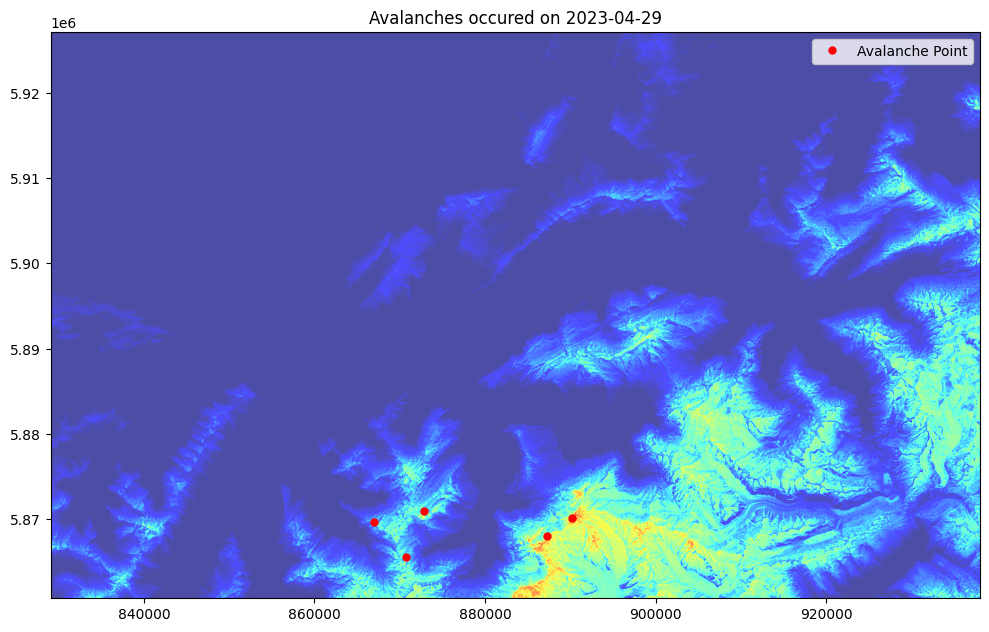

In [44]:
###plot avalanches on day 2023-04-01 from new_df

import matplotlib.pyplot as plt
from rasterio.plot import show  # Correct way to plot raster data
import rasterio
from pyproj import Transformer

tif_path = tif_path_from_date('2023-04-29')
transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
date = '2023-04-29'

with rasterio.open(tif_path) as src:
    band = src.read(1)
    transform = src.transform  # Affine transform for pixel <-> world coords

    fig, ax = plt.subplots(figsize=(10, 10))
    
    # Plot the raster correctly using rasterio.plot.show
    show(band, transform=transform, cmap='jet', ax=ax, alpha=0.7)

    ax.set_title('Avalanches occured on ' + date)   


    # Plot avalanche points
    for _, row in natural_df.iterrows():
        if date in row['trigger_date_time']:
            lon = row['lon']
            lat = row['lat']
            x_3857, y_3857 = transformer.transform(lon, lat)
            ax.plot(x_3857, y_3857, 'ro', markersize=5, label='Avalanche Point')

    # Optional: show legend only once
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend([handles[0]], [labels[0]])

plt.tight_layout()
plt.show()


In [7]:
### ADD ELEVATION PROFILE 

Coordinate is out of bounds.


In [49]:
###WEATHER STATION DATA MAPPING 
file_path = '../Data/full_dataset.csv'

import pandas as pd

df = pd.read_csv(file_path)

# Extract the unique station codes along with their lon and lat
unique_stations = df[['station_code', 'lon', 'lat']].drop_duplicates()

unique_stations.dropna(inplace=True)
print(unique_stations)

from pyproj import Proj, transform


epsg4326 = Proj(init="epsg:4326")
epsg3857 = Proj(init="epsg:3857")

# Define the bounding box in EPSG:3857
bounding_box = {
    'left': 829059.4892686082,
    'bottom': 5860743.433705239,
    'right': 938039.4892686082,
    'top': 5927163.433705239
}
df = unique_stations
# Function to convert lon/lat to EPSG:3857
def lonlat_to_epsg3857(lon, lat):
    x, y = transform(epsg4326, epsg3857, lon, lat)
    return x, y

# Filter stations within the bounding box
stations_in_bbox = []

for index, row in df.iterrows():
    lon, lat = row['lon'], row['lat']
    
    # Convert to EPSG:3857
    x, y = lonlat_to_epsg3857(lon, lat)
    
    # Check if the station is within the bounding box
    if bounding_box['left'] <= x <= bounding_box['right'] and bounding_box['bottom'] <= y <= bounding_box['top']:
        stations_in_bbox.append(row['station_code'])

# Output the stations that are within the bounding box
print("Stations within the bounding box (EPSG:3857):")
print(stations_in_bbox)


/var/folders/lj/yyssz_p12f50nl5zkgxpqy5h0000gn/T/ipykernel_52568/1728435207.py:5: DtypeWarning: Columns (91) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
/Users/ilyayakushevskiy/.pyenv/versions/3.12.0/lib/python3.12/site-packages/pyproj/crs/crs.py:143: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
/Users/ilyayakushevskiy/.pyenv/versions/3.12.0/lib/python3.12/site-packages/pyproj/crs/crs.py:143: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6


      station_code       lon        lat
3653          DIA2  7.241038  46.315405
3696          GLA2  9.037583  46.996629
3825          TUJ3  8.740224  46.647032
3913          OBW2  8.315956  46.545222
3957          URS2  8.513860  46.586787
...            ...       ...        ...
11082         KES2  9.898140  46.621285
11122         LAG2  9.744580  46.451358
11162         FUL2  7.089661  46.194685
11163         ILI2  6.827797  46.191356
11203         FIR2  8.064403  46.668777

[95 rows x 3 columns]
Stations within the bounding box (EPSG:3857):
['OBW2', 'GAD2', 'TIT2', 'FAE2', 'GUT2', 'OTT2', 'ROA2', 'SCH2', 'MAE2', 'SCB2', 'OBW3', 'TIT2', 'GAD2', 'OBW3', 'GUT2', 'ROA2', 'FIR2']


In [20]:
# import matplotlib.pyplot as plt

# fig, axes = plt.subplots(4, 3, figsize=(12, 8))  

# for i in range(12):
#     ax = axes[i // 3, i % 3]
#     ax.imshow(tif_files[i], cmap='jet') 
#     ax.set_title(f"Image {i}")
#     ax.axis('off')

# plt.tight_layout()
# plt.show()


In [22]:
### WEATHER STATION DATA



# Load station metadata
stations_df = pd.read_csv('./meta_stations.csv', sep=';')

# Transformer from EPSG:4326 to EPSG:3857
transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)

# Transform and filter
def is_in_bounds(lon, lat):
    x, y = transformer.transform(lon, lat)
    return (829059.4892686082 <= x <= 938039.4892686082) and (5860743.433705239 <= y <= 5927163.433705239)

stations_df['in_bounds'] = stations_df.apply(lambda row: is_in_bounds(row['station_coordinates_wgs84_lon'], row['station_coordinates_wgs84_lat']), axis=1)
stations_in_bounds = stations_df[stations_df['in_bounds']]

print(stations_in_bounds["station_abbr"])


23     BRZ
52     ENG
56     FLU
58     FRU
61     GIH
69     GRH
79     INT
80     JUN
94     MER
143    THU
144    TIT
146    ULR
Name: station_abbr, dtype: object


In [50]:
stations = {} 

for _, row in stations_in_bounds.iterrows():
    station_code = row['station_abbr']
    lon = row['station_coordinates_wgs84_lon']
    lat = row['station_coordinates_wgs84_lat']

    # Convert to EPSG:3857
    #x_3857, y_3857 = transformer.transform(lon, lat)
    station_code_small_literals = station_code.lower()
    station_path = f'./meteoswiss_data/ogd-smn_{station_code_small_literals}_h_historical_2020-2029.csv'
    stations[station_code] = (lon, lat, station_path) 



In [51]:
###MATCH DATA FROM CLOTHEST STATION (1-5KM range )
import numpy as np 
brz_data = pd.read_csv('./meteoswiss_data/ogd-smn_brz_h_historical_2020-2029.csv', sep=';')



new_df['closest_station'] = None
distances = 0
# Iterate over each avalanche record
for i, row in new_df.iterrows():
    lon_av = row['lon']
    lat_av = row['lat']

    # Track the closest station: (station_code, lon, lat, distance)
    closest_station = (None, None, None, float('inf'))

    for station_code, (lon_st, lat_st, station_path) in stations.items():
        distance = np.sqrt((lon_av - lon_st)**2 + (lat_av - lat_st)**2) * 111139  # approx meters
        
        if distance < closest_station[3]:
            closest_station = (station_code, lon_st, lat_st, distance)

    closest_station_code = closest_station[0]
    distances += closest_station[3]
    
    
    new_df.at[i, 'closest_station'] = closest_station_code

   # print(f"Closest station for avalanche {row['avalanche_id']} is {closest_station_code} with distance {closest_station[3]:.2f} m")

avg_distance = distances / len(new_df)
# Display results
print(f"Average distance to closest station: {avg_distance:.2f} m")
new_df.head()


Average distance to closest station: 4325.79 m


,avalanche_id,location,trigger_date_time,trigger_date_time_accuracy_code,trigger_type,avalanche_type,avalanche_size,avalanche_moisture,start_zone_aspect,snow_depth_sat,lat,lon,closest_station
0,110f1420-d9f1-11ed-8014-25b7abf6ec82,8.252181 46.759933,2023-04-13 02:00:00.000 +0200,4,NATURAL,FULL_DEPTH,2,WET,S,54,46.759933,8.252181,MER
1,dda75b80-ddc2-11ed-b3b1-431b3c02902e,8.263291 46.74286,2023-04-17 14:30:00.000 +0200,1,SNOW_GROOMER,SLAB,3,DRY,SE,127,46.742860,8.263291,MER
2,20077a30-ec16-11ed-aa20-6507e99101f4,8.022203 46.505884,2023-05-06 14:00:00.000 +0200,0,PERSON,SLAB,2,WET,E,90,46.505884,8.022203,JUN
3,c8a8b700-feb1-11ed-b35a-bf420b8ac344,8.01247 46.561817,2023-05-28 12:00:00.000 +0200,6,PERSON,SLAB,2,DRY,SE,201,46.561817,8.012470,JUN
4,0d6a183c-f453-4a31-98c7-90213921e278,8.417328 46.785788,2023-04-01 06:30:00.000 +0200,2,EXPLOSIVE,SLAB,1,DRY,NW,79,46.785788,8.417328,TIT


In [57]:
### ADD ALL WEATHER STATION DATA TO AVALANCHE DATA

for i, row in new_df.iterrows():
    station_code = row['closest_station']
    station_path = stations[station_code][2]
    
    # Load the station data
    station_data = pd.read_csv(station_path, sep=';')

    # Try converting to datetime
    try:
        station_data['reference_timestamp'] = pd.to_datetime(
            station_data['reference_timestamp'], 
            format="%d.%m.%Y %H:%M", 
            errors='coerce'
        )
    except Exception as e:
        print(f"Date parsing failed for station {station_code}: {e}")
        continue

    # Drop rows where timestamp parsing failed
    station_data = station_data.dropna(subset=['reference_timestamp'])

    # Confirm it's datetime dtype
    if not pd.api.types.is_datetime64_any_dtype(station_data['reference_timestamp']):
        print(f"reference_timestamp is not datetime for station {station_code}")
        continue

    # Make tz-naive (in case it’s tz-aware)
    station_data['reference_timestamp'] = station_data['reference_timestamp'].dt.tz_localize(None)

    # Avalanche time
    avalanche_dt = pd.to_datetime(row['trigger_date_time'], errors='coerce')
    if pd.notna(avalanche_dt) and avalanche_dt.tzinfo is not None:
        avalanche_dt = avalanche_dt.tz_localize(None)

    if pd.isna(avalanche_dt) or station_data.empty:
        print(f"Skipping row {i} due to date parse error or empty station data")
        continue

    # Compute time differences
    time_diffs = np.abs((station_data['reference_timestamp'] - avalanche_dt).dt.total_seconds())
    closest_idx = time_diffs.idxmin()
    closest_row = station_data.loc[closest_idx]

    # Copy data to avalanche row
    for col in station_data.columns:
        if col != 'reference_timestamp':
            new_df.at[i, col] = closest_row[col]

    



In [59]:
new_df.to_csv('./avalanche_sat+weather_all.csv', index=False)

In [69]:
#how much non avalanche days should we impute? 
df3  = pd.read_csv('../Data/dataset1.csv')

no_avalanches = 0 
avalanche_day = 0

ava_days = df3["avalancheDay1"].sum()
no_avalanches = df3.shape[0] - avalanche_day
print(f"Number of avalanches: {ava_days/(no_avalanches+ava_days)} days")

Number of avalanches: 0.09958097116095638 days


Elevation at (46.9481,7.4474): 551.0 meters


In [ ]:
#FIND Random points on the map and impute them to our dataset  (90%) with non avalanche days